# Label extraction

### Introduction

We don't need perfect labels here. The image model will train on ~4,349 LLM-pseudo-labeled studies, and deep nets tolerate a surprising amount of label noise without a comparable drop in test performance *as long as the noise is unbiased* (random misses that vary case-by-case, not a consistent skew in one direction). What actually caps downstream performance is **systematic** bias: a condition the labeler consistently over or under-calls. Section 2 below checks both the overall agreement rate and, specifically, whether any condition's errors are directionally biased rather than random.

### Contents

- **Calibration review** how well does the labeler agree with the 58 gold rows?
- **Pseudo-labeled dataset QA** QA of the fully-labeled dataset the Luigi pipeline produces.

### Reading list

- Rolnick, Veit, Belongie & Shavit (2017), ["Deep Learning is Robust to Massive Label Noise"](https://arxiv.org/abs/1711.10370): CNNs tolerate very high noise-to-signal ratios given enough data; *random* noise is far less damaging than *systematic* noise.
- Zhang, Bengio, Hardt, Recht & Vinyals (2017), ["Understanding Deep Learning Requires Rethinking Generalization"](https://arxiv.org/pdf/1611.03530) (ICLR): deep nets can memorize pure random labels, so robustness isn't unconditional; there must be real signal to lock onto alongside the noise.
- Patrini, Rozza, Krishna Menon, Nock & Qu (2017), ["Making Deep Neural Networks Robust to Label Noise: A Loss Correction Approach"](https://arxiv.org/pdf/1609.03683) (CVPR): loss-correction methods for when the noise transition matrix (i.e. directional bias) is known or estimable.
- Natarajan, Dhillon, Ravikumar & Tewari (2013), ["Learning with Noisy Labels"](https://proceedings.neurips.cc/paper_files/paper/2013/file/3871bd64012152bfb53fdf04b401193f-Paper.pdf) (NeurIPS): theoretical foundation for risk-consistent learning under class-conditional (asymmetric) label noise.
- Song, Kim, Park, Shin & Lee (2022), ["Learning from Noisy Labels with Deep Neural Networks: A Survey"](https://arxiv.org/pdf/2007.08199) (IEEE TNNLS): broad survey tying the above together.


## 1. Notebook setup

### 1.1. Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix, roc_curve

import configuration as config
import data_pipeline.label_extraction.config as pipeline_config # noqa: E402
from helper_funcs.label_extraction import (
    failed_uid_count, load_calibration_cmp, mcnemar_bias,
    per_condition_metrics, run_model_name
)

### 1.2. Configuration

In [2]:
CALIBRATION_RUNS = ['20260909_gpt20B']
LABEL_RUN        = '20260909_001'

### 1.3. Reference: local inference server deployment settings

Six candidate deployments on 2x P100 (16GB each, Pascal — no bf16, skip `--flash-attn`), one identical process per GPU (`CUDA_VISIBLE_DEVICES=0` → port 8503, `=1` → port 8504).

**Context sizing:** `llama-server` splits `--ctx-size` evenly across `--parallel` slots. The original settings gave only ~2048 tokens/slot, not enough for the system prompt (multilingual glossary for 12 conditions) + few-shot exemplar + structured-output JSON schema. The `20260909_qwen14B` calibration run hit repeated `Context size has been exceeded` (HTTP 500) on longer, mostly non-English gold reports. Settings below now target ~4096 tokens/slot across the board.

#### GPT-OSS-20B 

**current MoE baseline**: `--parallel 12` + `--workers 24` confirmed via `nvidia-smi dmon -s um`: `sm` ~98%, with `mem` in the teens, so this is now compute-bound, not memory-bandwidth-bound; 8 slots per card with 16 workers left cards underfed)

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model gpt-oss-20b-Q4_K_M.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 49152 --parallel 12 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Qwen2.5-14B-Instruct

**Top pick**: structured output + multilingual)

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model Qwen2.5-14B-Instruct-Q4_K_M.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 40960 --parallel 10 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Qwen2.5-7B-Instruct

**Fastest**: try if 14B accuracy holds up

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model Qwen2.5-7B-Instruct-Q8_0.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 49152 --parallel 12 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Phi-4 (14B)

Alternate strong-reasoning candidate from Microsoft

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model phi-4-Q4_K_M.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 40960 --parallel 10 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Llama-3.1-8B-Instruct

Meta lineage, a classic.

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model Meta-Llama-3.1-8B-Instruct-Q8_0.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 49152 --parallel 12 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Gemma-2-9B-it

Google lineage, strong instruction following at small size.

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model gemma-2-9b-it-Q4_K_M.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 40960 --parallel 10 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

The other five settings above are bumped the same way as the GPT-OSS-20B (more `--parallel` slots, `--ctx-size` scaled to hold ~4096 tokens/slot) so continuous batching has enough in-flight requests to keep both cards fed. Dense models (all five, vs. GPT-OSS-20B's MoE) do full-parameter compute per token, so they may hit an SM ceiling at a lower `--parallel` than 12. The 14B models (Qwen2.5-14B, Phi-4) are bumped more conservatively (6→10) than the ~7-9B models (6-8→12) for that reason. Treat these as starting points, not confirmed numbers: redo the same `nvidia-smi dmon -s um` check (SM vs. mem columns) used for GPT-OSS-20B on each candidate before its own calibration run, and back off `--parallel`/`--ctx-size` if VRAM is tight (16GB/card) rather than assuming more slots always helps.

Repeat each command with `CUDA_VISIBLE_DEVICES=1 --port 8504` for the second identical server. If `--parallel` changes, update `SLOTS_PER_LOCAL_SERVER` in `config.py` to match, and pass `--workers <2 x parallel>` on the CLI (e.g. `--workers 24` for GPT-OSS-20B at `--parallel 12`, `--workers 20` for the 14B models at `--parallel 10`) so enough requests are in flight to actually use the extra slots.

**Recovering a run with context-overflow rows:** after redeploying with a bigger `--ctx-size`, delete just the affected rows so Luigi re-does them (their existing output files satisfy the target check otherwise): `rm data/pipeline/label_extraction/<run_id>/calibration_rows/{uid}.json` for each `uid` listed in `data/pipeline/label_extraction/<run_id>/failed_uids.txt`, then re-run `python3 -m data_pipeline.pipeline calibrate --run <run_id>`.

**Marking a calibration trial by model:** encode the model into the run id when calibrating (e.g. `--run 20260909_qwen14b`, `--run 20260909_gptoss20b`), `RunCalibration` now also writes `run_meta.json` (model name, server URLs, samples-per-report, completion time) into the run directory for provenance, so a run's model doesn't rely on naming discipline alone.

## 2. Calibration review

Multi-model first: load every calibration trial, score them all the same way, compare, then dig into the best one.

### 2.1. Load gold training labels

In [3]:
# Gold rows (58 studies with original labels) - the fixed reference every
# trial is compared against.
raw = pd.read_csv(config.TRAIN_CSV)
label_cols = [c for c in raw.columns if c not in ('StudyInstanceUID', 'Report')]
gold_mask = raw[label_cols].notna().any(axis=1)
gold = raw[gold_mask].set_index('StudyInstanceUID')

print(f'{len(gold)} gold rows, {len(label_cols)} conditions')

58 gold rows, 12 conditions


### 2.2. Load and parse calibration runs

In [15]:
# List every calibration trial to compare (one run id per model/deployment -
# see section 1.3). Add new run ids here as they complete.
cmp = {r: load_calibration_cmp(r, label_cols, gold) for r in CALIBRATION_RUNS}

for r in CALIBRATION_RUNS:
    meta_f = pipeline_config.OUTPUT_ROOT / r / 'run_meta.json'

    if meta_f.exists() is False:
        print(f'--- {r}: no run_meta.json (older run, predates provenance tracking) ---')

    n_failed = failed_uid_count(r)
    warn = f' -- WARNING: {n_failed} rows failed (see failed_uids.txt) and load as empty predictions' if n_failed else ''
    print(f'Run {r}: {len(cmp[r])} rows loaded{warn}')

Run 20260909_gpt20B: 58 rows loaded


### 2.3. Score metrics per model

Per-condition accuracy, Cohen's kappa, ROC AUC and average precision for every trial. **Caveat:** the labeler emits a hard 0/1 vote per condition, not a probability, so ROC AUC here collapses to `0.5 * (TPR + TNR)` (balanced accuracy) rather than a true ranking-based AUC, and it's measured against only 58 gold *report-text* rows - not directly comparable to a competition leaderboard AUC (continuous-probability *image* model, much larger test set). Treat these as a sanity-check floor on label quality, not a proxy for achievable leaderboard score.

In [5]:
metrics_by_run = {r: per_condition_metrics(cmp[r], label_cols) for r in CALIBRATION_RUNS}

for r in CALIBRATION_RUNS:
    m = metrics_by_run[r]
    print(
        f'{r} ({run_model_name(r)}): mean accuracy={m["accuracy"].mean():.3f} '
        f'| mean kappa={m["kappa"].mean():.3f} | mean roc_auc={m["roc_auc"].mean():.3f}'
    )

metrics_by_run[CALIBRATION_RUNS[0]].round(3)

20260909_gpt20B (default): mean accuracy=0.807 | mean kappa=0.568 | mean roc_auc=0.805


,gold_pos,pred_pos,accuracy,kappa,roc_auc,avg_precision,false_neg,false_pos
condition,,,,,,,,
ACL,24,33,0.845,0.697,0.868,0.727,0,9
MCL,9,17,0.862,0.614,0.918,0.529,0,8
Medial Meniscus,26,30,0.828,0.656,0.833,0.730,3,7
Lateral Meniscus,23,23,0.862,0.712,0.856,0.751,4,4
Medial OA,15,18,0.879,0.705,0.875,0.660,2,5
Lateral OA,11,16,0.845,0.570,0.835,0.495,2,7
PF OA,21,22,0.741,0.446,0.725,0.545,7,8
Effusion,35,50,0.741,0.392,0.674,0.700,0,15
Synovitis,27,16,0.672,0.324,0.658,0.592,15,4


### 2.3. McNemar's test per model (directional bias)

[McNemar's exact test](https://en.wikipedia.org/wiki/McNemar%27s_test): gold and the LLM are two paired raters scoring the same 58 studies. Random disagreements (sometimes gold-only, sometimes LLM-only, roughly balanced) tend to average out during downstream training. Systematic bias (e.g. "the LLM almost always calls this condition when gold doesn't") does not; it teaches the image model a consistent skew. This checks, per condition per trial, whether the two types of discordant pairs (gold=0/LLM=1 vs gold=1/LLM=0) are significantly different from a 50/50 split; a small p-value with a lopsided ratio flags directional bias rather than noise.

In [6]:
bias_by_run = {r: mcnemar_bias(cmp[r], label_cols) for r in CALIBRATION_RUNS}

for r in CALIBRATION_RUNS:
    n_sig = int((bias_by_run[r]['mcnemar_p'] < 0.05).sum())
    print(f'{r} ({run_model_name(r)}): {n_sig}/{len(label_cols)} conditions with significant directional bias')

bias_by_run[CALIBRATION_RUNS[0]]

20260909_gpt20B (default): 5/12 conditions with significant directional bias


,false_pos,false_neg,n_discordant,bias_direction,mcnemar_p,flag
condition,,,,,,
Effusion,15,0,15,over-calls,0.000061,*** significant bias ***
ACL,9,0,9,over-calls,0.003906,*** significant bias ***
MCL,8,0,8,over-calls,0.007812,*** significant bias ***
Synovitis,4,15,19,under-calls,0.019211,*** significant bias ***
Contusion,15,4,19,over-calls,0.019211,*** significant bias ***
Lateral OA,7,2,9,over-calls,0.179688,
Baker's,5,1,6,over-calls,0.218750,
Medial Meniscus,7,3,10,over-calls,0.343750,
Medial OA,5,2,7,over-calls,0.453125,


### 2.4. Compare performance across models

In [7]:
compare_tbl = pd.DataFrame([
    {
        'run_id': r,
        'model': run_model_name(r),
        'mean_accuracy': metrics_by_run[r]['accuracy'].mean(),
        'mean_kappa': metrics_by_run[r]['kappa'].mean(),
        'mean_roc_auc': metrics_by_run[r]['roc_auc'].mean(),
        'mean_ap': metrics_by_run[r]['avg_precision'].mean(),
        'n_significant_bias': int((bias_by_run[r]['mcnemar_p'] < 0.05).sum()),
    }
    for r in CALIBRATION_RUNS
]).set_index('run_id').sort_values('mean_roc_auc', ascending=False)

BEST_RUN = compare_tbl.index[0]
print(f'Best model by mean ROC AUC: {compare_tbl.loc[BEST_RUN, "model"]} ({BEST_RUN})')

compare_tbl.round(3)

Best model by mean ROC AUC: default (20260909_gpt20B)


,model,mean_accuracy,mean_kappa,mean_roc_auc,mean_ap,n_significant_bias
run_id,,,,,,
20260909_gpt20B,default,0.807,0.568,0.805,0.623,5


In [8]:
# Per-condition ROC AUC, one column per trial - shows which conditions
# drive any gap between candidate models rather than just the average.
pd.DataFrame({
    f'{run_model_name(r)} ({r})': metrics_by_run[r]['roc_auc']
    for r in CALIBRATION_RUNS
}).round(3)

,default (20260909_gpt20B)
condition,
ACL,0.868
MCL,0.918
Medial Meniscus,0.833
Lateral Meniscus,0.856
Medial OA,0.875
Lateral OA,0.835
PF OA,0.725
Effusion,0.674
Synovitis,0.658


### 2.5. Detailed work-up: best model

Confusion matrices, ROC curves and per-condition error drilldown for `BEST_RUN` only (set by section 2.4).

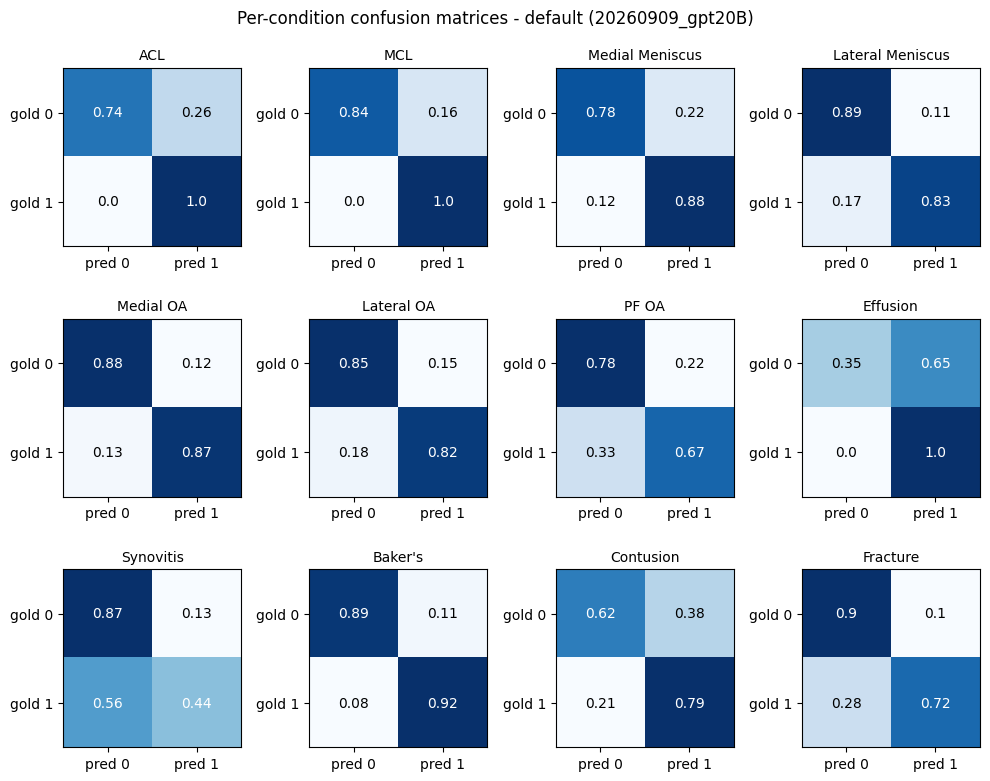

In [9]:
best_df = cmp[BEST_RUN]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, c in zip(axes.flat, label_cols):
    g = (best_df[f'{c}_label'].fillna(0) == 1).astype(int).values
    p = (best_df[f'{c}_pred'].fillna(0) == 1).astype(int).values
    cm = confusion_matrix(g, p, labels=[0, 1], normalize='true')

    ax.imshow(cm, cmap='Blues')
    ax.set_title(c, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['gold 0', 'gold 1'])

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, round(cm[i, j], 2), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

fig.suptitle(f'Per-condition confusion matrices - {run_model_name(BEST_RUN)} ({BEST_RUN})')
fig.tight_layout()
plt.show()

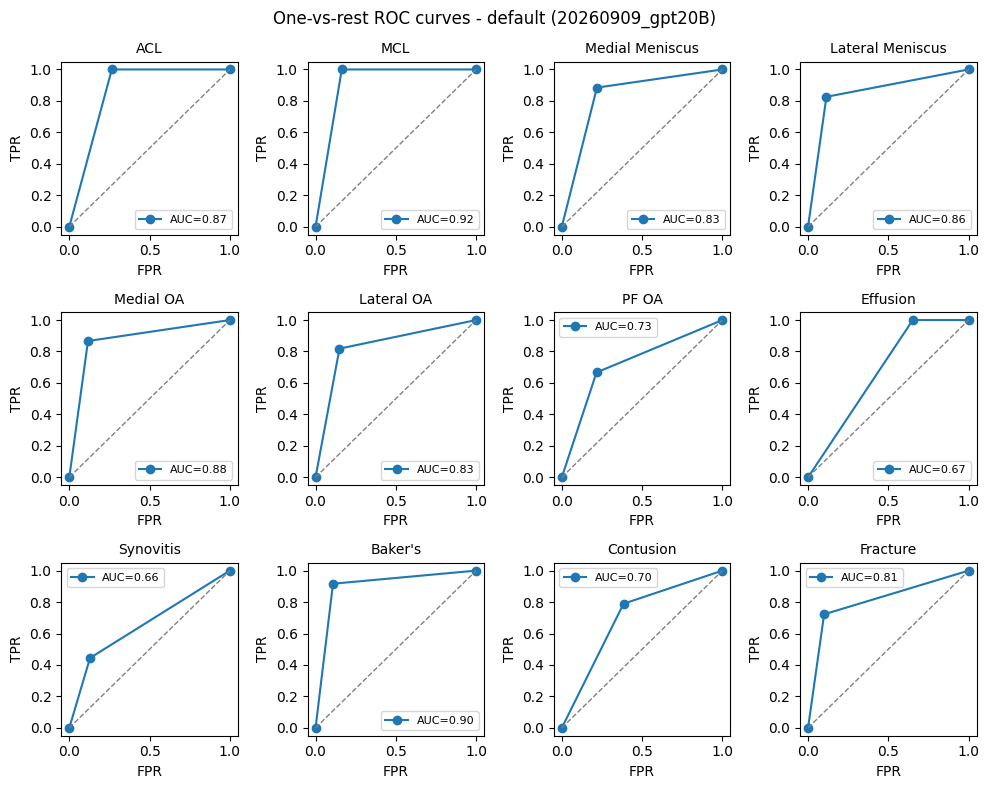

In [10]:
# One-vs-rest ROC curves (hard 0/1 predictions -> single operating point per
# condition; see caveat in 2.2).
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, c in zip(axes.flat, label_cols):
    g = (best_df[f'{c}_label'].fillna(0) == 1).astype(int).values
    p = (best_df[f'{c}_pred'].fillna(0) == 1).astype(int).values

    fpr, tpr, _ = roc_curve(g, p)
    auc_score = metrics_by_run[BEST_RUN].loc[c, 'roc_auc']

    ax.plot(fpr, tpr, marker='o', label=f'AUC={auc_score:.2f}')
    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
    ax.set_title(c, fontsize=10)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

fig.suptitle(f'One-vs-rest ROC curves - {run_model_name(BEST_RUN)} ({BEST_RUN})')
fig.tight_layout()
plt.show()

In [11]:
# Errors per condition for the best model, worst-bias-first (from 2.3).
review_conds = bias_by_run[BEST_RUN].index.tolist()

for cond in review_conds:
    g = (best_df[f'{cond}_label'].fillna(0) == 1).astype(int).values
    p = (best_df[f'{cond}_pred'].fillna(0) == 1).astype(int).values

    mm = best_df[(g == 1) & (p == 0) | (g == 0) & (p == 1)].copy()

    mm['gold'] = mm[f'{cond}_label'].fillna(0).astype(int)
    mm['pred'] = mm[f'{cond}_pred'].fillna(0).astype(int)
    mm['type'] = np.where((mm['gold'] == 1) & (mm['pred'] == 0), 'missed', 'false')

    print(f'{cond}: {len(mm)} mismatches -> {dict(mm["type"].value_counts())}')

    if not mm.empty:
        display(mm[['gold', 'pred', 'type']])

Effusion: 15 mismatches -> {'false': np.int64(15)}


,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269,0,1,false
1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052,0,1,false
1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756,0,1,false
1.2.826.0.1.3680043.8.498.12978510157202852202776899910529174803,0,1,false
1.2.826.0.1.3680043.8.498.13267780356245120052411517053322874891,0,1,false
1.2.826.0.1.3680043.8.498.15593638897292057356864060466120253309,0,1,false
1.2.826.0.1.3680043.8.498.22109739962224309418874538994436903404,0,1,false
1.2.826.0.1.3680043.8.498.26790702379506190936834447203448882465,0,1,false
1.2.826.0.1.3680043.8.498.29764868091238287072166823522853419550,0,1,false


ACL: 9 mismatches -> {'false': np.int64(9)}


,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.11548045715264151632153040089882701935,0,1,false
1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756,0,1,false
1.2.826.0.1.3680043.8.498.13267780356245120052411517053322874891,0,1,false
1.2.826.0.1.3680043.8.498.15593638897292057356864060466120253309,0,1,false
1.2.826.0.1.3680043.8.498.37392127307867238524251864751713143683,0,1,false
1.2.826.0.1.3680043.8.498.47921753480592595198052407850568677187,0,1,false
1.2.826.0.1.3680043.8.498.64408609256163127278435484217683272910,0,1,false
1.2.826.0.1.3680043.8.498.64703506772167798469048460791472465039,0,1,false
1.2.826.0.1.3680043.8.498.78512215519177850923279235346968676828,0,1,false


MCL: 8 mismatches -> {'false': np.int64(8)}


...

,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,0,1,false
1.2.826.0.1.3680043.8.498.11548045715264151632153040089882701935,0,1,false
1.2.826.0.1.3680043.8.498.12801308844398614687904447633432197492,1,0,missed
1.2.826.0.1.3680043.8.498.13335129881737731410081002627729200903,1,0,missed
1.2.826.0.1.3680043.8.498.28925345859498351203477642741908452608,1,0,missed
1.2.826.0.1.3680043.8.498.41600498783384864111179175518614837125,0,1,false
1.2.826.0.1.3680043.8.498.62549354677638403845904556149868367236,1,0,missed
1.2.826.0.1.3680043.8.498.97274720257634584071500649275217521662,0,1,false


PF OA: 15 mismatches -> {'false': np.int64(8), 'missed': np.int64(7)}


,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1,0,missed
1.2.826.0.1.3680043.8.498.16060119389060497136231217718921482192,1,0,missed
1.2.826.0.1.3680043.8.498.22109739962224309418874538994436903404,0,1,false
1.2.826.0.1.3680043.8.498.28925345859498351203477642741908452608,1,0,missed
1.2.826.0.1.3680043.8.498.37392127307867238524251864751713143683,0,1,false
1.2.826.0.1.3680043.8.498.48946580946665031852355005294734101132,0,1,false
1.2.826.0.1.3680043.8.498.54977581323931277817074741182670080450,0,1,false
1.2.826.0.1.3680043.8.498.56512564464301544960446419143135447363,1,0,missed
1.2.826.0.1.3680043.8.498.62465595376489211274225312453216559395,0,1,false


Fracture: 9 mismatches -> {'missed': np.int64(5), 'false': np.int64(4)}


,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269,0,1,false
1.2.826.0.1.3680043.8.498.12505035424093604269515328931488770819,1,0,missed
1.2.826.0.1.3680043.8.498.29764868091238287072166823522853419550,1,0,missed
1.2.826.0.1.3680043.8.498.30246079718471552972130572444383079911,1,0,missed
1.2.826.0.1.3680043.8.498.32321830776739689645700555055955725945,1,0,missed
1.2.826.0.1.3680043.8.498.39500553372517290823815606829518305500,0,1,false
1.2.826.0.1.3680043.8.498.62549354677638403845904556149868367236,0,1,false
1.2.826.0.1.3680043.8.498.75187434248356774277526985329346125190,0,1,false
1.2.826.0.1.3680043.8.498.97274720257634584071500649275217521662,1,0,missed


## Pseudo-labeled dataset QA

Set `RUN_ID` below to the run (the one from `pipeline.py build --run ...`).

In [12]:
pipeline_config.OUTPUT_ROOT

PosixPath('/workspaces/RSNA-knee-abnormality/data/pipeline/label_extraction')

In [13]:
merged_f = pipeline_config.OUTPUT_ROOT / LABEL_RUN / config.MERGED_CSV_NAME

print(
    'merged dataset:', merged_f, 'exists:',
    merged_f.exists() if merged_f is not None else 'set RUN_ID first'
)

merged = pd.read_csv(merged_f) if merged_f and merged_f.exists() else None

print('label_source:\n', merged['label_source'].value_counts().to_string())
pseudo = merged[merged['label_source'] == config.LABEL_SOURCE_PSEUDO]
print('\npseudo_status:\n', pseudo['pseudo_status'].value_counts().to_string())
failed_f = pipeline_config.OUTPUT_ROOT / LABEL_RUN / 'failed_uids.txt'

if failed_f.exists():
    print('\nfailed_uids.txt lines:',
            sum(1 for _ in open(failed_f, encoding='utf-8')))

AttributeError: module 'configuration' has no attribute 'MERGED_CSV_NAME'

In [ ]:
# Pseudo-label distribution: how 'abnormal' does the pseudo-labeled cohort
# look? (Sanity check: expect a skewed, mostly-zero distribution.)
if merged is not None:
    pseudo = merged[merged['label_source'] == config.LABEL_SOURCE_PSEUDO].copy()
    ok = ~pseudo['pseudo_status'].isin(['failed', 'unparseable'])
    pos = (pseudo.loc[ok, label_cols].fillna(0) == 1).sum()

    dist = pd.DataFrame({
        'condition': label_cols,
        'n_pseudo': int(ok.sum()),
        'positives': pos.values,
        'positive_rate': (pos / ok.sum()).map(lambda x: f'{x:.1%}'),
    }).set_index('condition')

    print(
        'mean positives per report:',
        round(pseudo.loc[ok, label_cols].fillna(0).sum(axis=1).mean(), 2)
    )

    dist

### Spot-check: 20 random pseudo-labeled reports with evidence quotes

The per-UID JSON files under `labels/` carry the evidence strings the model quoted; these are the raw material for manual QA. Sample 20 and eyeball whether the quotes actually support the labels.

In [ ]:
if merged is None:
    raise SystemExit('Set RUN_ID first (cell above).')

pseudo = merged[merged['label_source'] == config.LABEL_SOURCE_PSEUDO]
pseudo = pseudo[pseudo['pseudo_status'] == 'pseudo']
raw = pd.read_csv(config.TRAIN_CSV).set_index('StudyInstanceUID')
labs_dir = pipeline_config.OUTPUT_ROOT / LABEL_RUN / 'labels'

rng = np.random.default_rng(42)
pick = rng.choice(pseudo['StudyInstanceUID'].values, size=min(20, len(pseudo)))

records = []

for uid in pick:
    rec = json.loads((labs_dir / f'{uid}.csv').read_text())
    pos = {c: rec[f'{c}_evidence'] for c in label_cols if rec.get(c) == 1}

    records.append({
        'uid': uid[:22] + '...',
        'n_positives': len(pos),
        'positives': ', '.join(pos) or '-',
        'evidence': ' | '.join(f'[{c}] {e}' for c, e in pos.items()) or '-',
        'report': str(raw.loc[uid, 'Report'])[:500],
    })

sp = pd.DataFrame(records)

with pd.option_context('display.max_colwidth', 120):
    sp